In [ ]:
!pip install fastai -q

In [ ]:
from fastai.vision.all import *

In [ ]:
path = untar_data(URLs.PETS)
print(path.ls())

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:18&lt;00:00]</div>

[Path('/root/.fastai/data/oxford-iiit-pet/annotations'), Path('/root/.fastai/data/oxford-iiit-pet/images')]


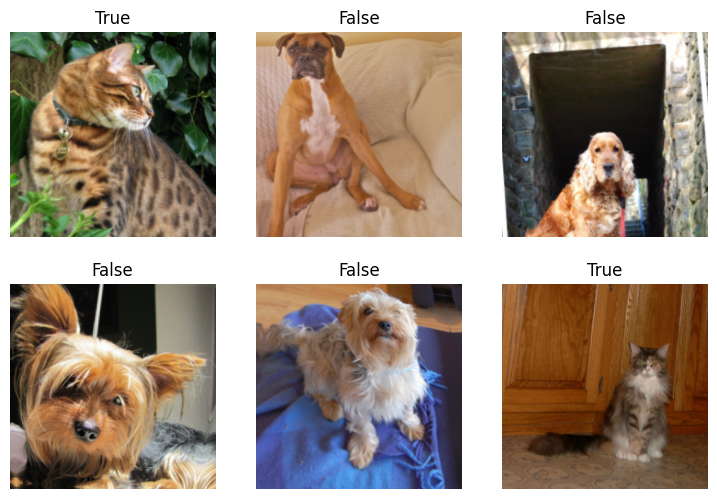

In [ ]:
dls = ImageDataLoaders.from_name_func(
    path/"images",
    get_image_files(path/"images"),
    valid_pct=0.2,
    seed=42,
    label_func=lambda x: Path(x).name[0].isupper(),  # ← Fixed here
    item_tfms=Resize(224),
    batch_tfms=aug_transforms()
)

dls.show_batch(max_n=6)

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 109MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.162250,0.024975,0.007442,00:44


epoch,train_loss,valid_loss,error_rate,time
0,0.073319,0.061282,0.016238,00:40
1,0.045608,0.006286,0.002030,00:43
2,0.019749,0.006078,0.002030,00:45


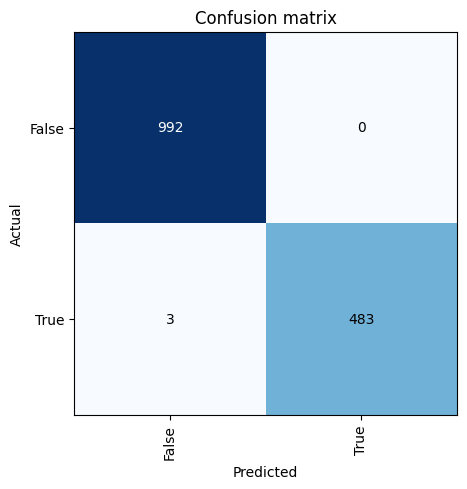

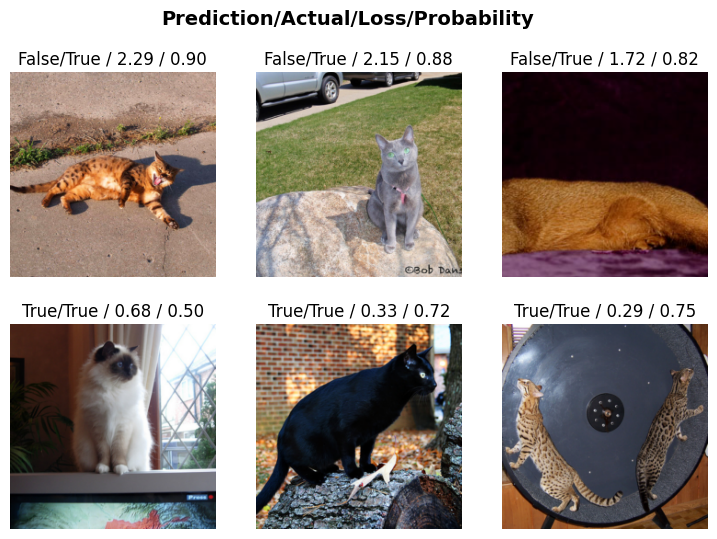

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(6)